*O dataset escolhido é sobre diabetes, tal escolha se deve ao fato de ter outra formação na área de saúde e ter buscado um dataset que me permita trabalhar um pouco com essas duas áreas. A idéia é que com um questionário simples sendo aplicado em uma pré-consulta o profissional da área de saúde já saiba um potencial problema do paciente e talvez solicitar antes da consulta exames bioquímicos visando dar maior base na primeira consulta e ajudar a tomar medidas visando mitigar riscos e ajudar na qualidade de vida do paciente.*

*A idéia do Machine learning é para automatizar uma função que um médico especializado em diabete precisaria fazer e perder tempo nisso, desse modo, financeiramente falando é econômico a utilização da mesma. Cabe ressaltar que a quantidade de dados e a legislação atual não permitiriam uma pessoa analisar os dados e assinalar um possível diagnóstico*

- Origem dos dados: Dataset do Kaggle contendo avaliação de saúde de pessoas nos EUA entre 2011 e 2015
- Volume aproximado de observações: 283mil pessoas analisadas
- Natureza das variáveis disponíveis: Temos variáveis contínuas (BMI), ordinais - faixas (Age, education, income) e binárias (as restantes)
- A definição explícita da variável-alvo, justificando por que o problema é formulado como classificação binária: A variável alvo é a Diabetes_012, nela o valor 0 significa sem diabetes, 1 pré-diabete e 2 diabete. Como o principal foco no trabalho é o tipo de tratamento a ser feito, vamos alterar o dataset para utilizar apenas 0 como sem diabetes e 1 como pré-diabete e diabetes, facilitando a classificação de indivíduos que necessitam de uma intervenção no seu estilo de vida;
- A descrição das features utilizadas, destacando o papel das variáveis contínuas e, se houver variáveis categóricas, justificando seu uso mediante validação do professor:
    - HighBP, HighChol, CholCheck, Smoker, Stroke, HeartDeseaseorAttack, PhysActivity, Fruits, Veggies, HvyAlcoholConsump, DiffWalk são questões de sim ou não comuns de serem realizadas na área da saúde, sendo indicadores comportamentais que se associam a qualidade de vida;
    - AnyHealthCare e NoDocbcCost são binários que nos revelam a razão de alguns desleixos com saúde (o porque);
    - GenHealth, MentHlth, PhysHlth são variáveis ordinais (GenHealth) e numéricas discretas (restantes) sobre a autopercepção do paciente quanto a sua saúde geral, e saúde mental e física no último mês;
    - Sex, Age, Education, Income são binário (sex) e categóricas (restante) que nos trazem fatores individuais do paciente que podem revelar comportamentos em relação a saúde (como homem se cuidar menos ou alguém mais pobre ter uma alimentação menos saudável)


*Importante ver que algumas variáveis se correlacionam, como o caso de dificuldade de andar (DiffWalk) e Reclamaçaõ sobre saúde física (PhysHlth). Desse modo, podemos fazer uma redução de dimensionalidade*

### Importar as bibliotecas e o dataset

In [121]:
import warnings
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

In [122]:
warnings.filterwarnings("ignore")
df = pd.read_csv("H:/Machine learning/Fundamentos de machine learning com sk-learn/diabetes_012_health_indicators_BRFSS2015.csv")
pd.set_option('display.max_columns', None) #para exibir todas as colunas
df.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


### Analisando o dataframe e higienizando se necessário

In [123]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

***Podemos ver que não há dados nulos na tabela e nem precisamos editar o nome de nenhuma coluna***

In [124]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Diabetes_012,253680.0,0.296921,0.698160,0.0,0.0,0.0,0.0,2.0
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0


***Nenhum dado apresentado está fora das classificações esperadas da sua coluna, com exceção do IMc (coluna BMI), vamos verificar quantos outliers temos***

In [125]:
obesidadeExtrema = df[df['BMI'] >= 60]
display(obesidadeExtrema)

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
2415,2.0,1.0,1.0,1.0,63.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,15.0,30.0,1.0,1.0,9.0,3.0,5.0
2486,2.0,1.0,1.0,1.0,61.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,4.0,3.0,30.0,1.0,1.0,9.0,5.0,6.0
2547,0.0,1.0,0.0,0.0,63.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,0.0,4.0,1.0,0.0,3.0,4.0,1.0
3125,0.0,1.0,0.0,1.0,61.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,3.0,3.0,5.0,1.0,0.0,5.0,5.0,2.0
3769,2.0,1.0,0.0,1.0,63.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,5.0,0.0,20.0,1.0,0.0,10.0,3.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
244309,0.0,1.0,1.0,1.0,95.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,5.0,9.0,1.0,0.0,8.0,4.0,5.0
244427,2.0,1.0,1.0,1.0,65.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,4.0,0.0,30.0,1.0,0.0,7.0,4.0,8.0
249875,0.0,0.0,0.0,1.0,63.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,5.0,0.0,0.0,0.0,6.0,5.0,5.0
252332,2.0,1.0,0.0,1.0,61.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,4.0,0.0,8.0,1.0,0.0,7.0,6.0,1.0


**Vamos utilizar o plt para ajudar a ver como estão esses outliers**

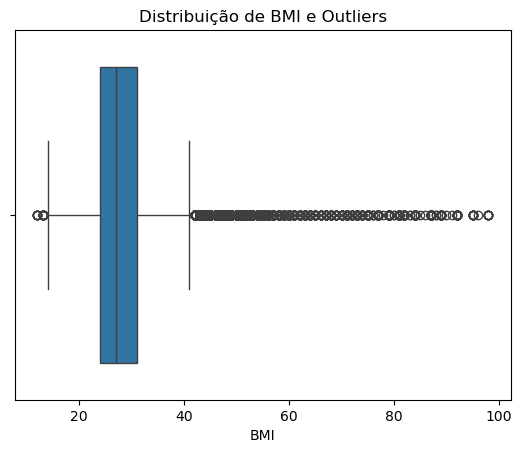

In [126]:
sns.boxplot(x=df['BMI'])
plt.title('Distribuição de BMI e Outliers')
plt.show()

**Considerando que tenho formação como nutricionista e que BMI acima de 40 já é considerada Obesidade extrema, BMI acima de 60 é algo anormal de se encontrar, tendo possibilidade de ser erro de digitação ou ser um caso muito atípico, desse modo, vou optar por excluir esses pacientes, tendo em vista que diabete não seria a principal preocupação com um paciente do tipo e que podem vir a distorcer a análise de dados**

In [127]:
# Gerando novo df sem os outliers
df2 = df[df['BMI'] < 60].copy()

# Verifica quantas linhas foram removidas
removidas = len(df) - len(df2)
print(f"Linhas originais: {len(df)}")
print(f"Linhas após filtragem: {len(df2)}")
print(f"Total de outliers removidos: {removidas}")

Linhas originais: 253680
Linhas após filtragem: 252812
Total de outliers removidos: 868


**Criando gráfico para ajudar a visualizar a diferença antes e depois da retirada dos outliers**

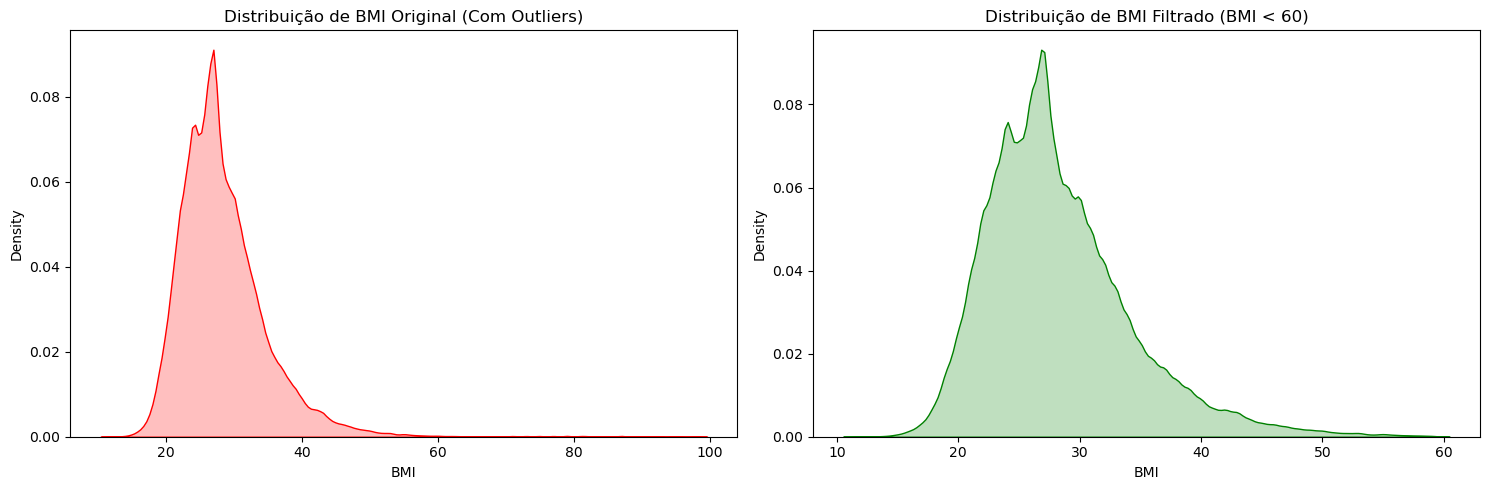

In [128]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Antes (Original)
sns.kdeplot(df['BMI'], ax=axes[0], fill=True, color='red')
axes[0].set_title('Distribuição de BMI Original (Com Outliers)')
axes[0].set_xlabel('BMI')

# Gráfico 2: Depois (Sem outliers)
sns.kdeplot(df2['BMI'], ax=axes[1], fill=True, color='green')
axes[1].set_title('Distribuição de BMI Filtrado (BMI < 60)')
axes[1].set_xlabel('BMI')

plt.tight_layout()
plt.show()

**Podemos ver que o menor espaçamento ajuda em uma melhor visualização dos dados**

In [129]:
# Proporção no dataset original
print("Proporção Original:")
print(df['Diabetes_012'].value_counts(normalize=True) * 100)

print("\nProporção após Filtro (BMI < 60):")
print(df2['Diabetes_012'].value_counts(normalize=True) * 100)

Proporção Original:
Diabetes_012
0.0    84.241170
2.0    13.933302
1.0     1.825528
Name: proportion, dtype: float64

Proporção após Filtro (BMI < 60):
Diabetes_012
0.0    84.272898
2.0    13.903612
1.0     1.823489
Name: proportion, dtype: float64


**Também vemos que não mudou praticamente as proporções das classificações de diabetes nos pacientes**

**Transformando coluna diabetes em binário**

In [130]:
df2['Diabetes'] = df2['Diabetes_012'].replace({1.0: 1.0, 2.0: 1.0})

# 3. Removendo a coluna antiga para não confundir o modelo
df2 = df2.drop(columns=['Diabetes_012'])

print(f"Novo formato do df2: {df2.shape}")
print("Distribuição da Variável Alvo:")
print(df2['Diabetes'].value_counts())

Novo formato do df2: (252812, 22)
Distribuição da Variável Alvo:
Diabetes
0.0    213052
1.0     39760
Name: count, dtype: int64


**Vamos criar um código que mostre a correlação direta entre as variáveis**

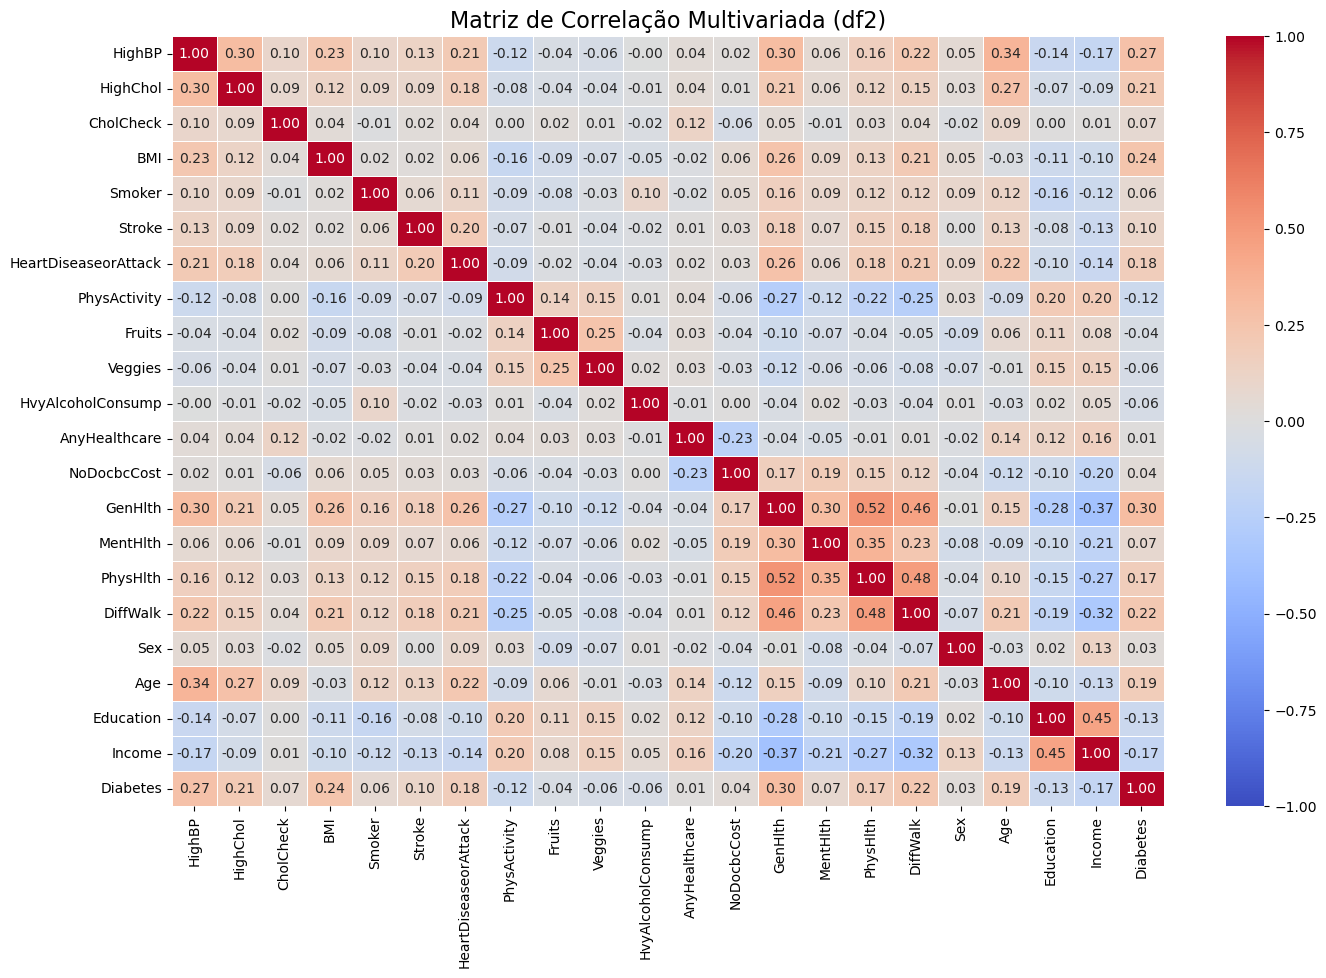

In [131]:
# Calcula a correlação de todas as colunas
corr = df2.corr()

# Criando o gráfico
plt.figure(figsize=(16, 10))

# Plotando o Heatmap
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', 
            vmin=-1, vmax=1, center=0, linewidths=.5)

plt.title('Matriz de Correlação Multivariada (df2)', fontsize=16)
plt.show()

*Podemos ver que DiffWalk e PhysHlth e GenHlth estão fortemente correlacionadas, podemos agrupas as mesmas em um único marcador como "Dificuldade Física"*

## Separando dados de treino e testes

In [132]:
# Separando as features (X) e o alvo (y)
x = df2.drop(columns=['Diabetes'])
y = df2['Diabetes']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=33, stratify=y) #stratify para manter a proporção da variável alvo


## Aplicando o PCA

*Primeiramente vamos equalizar as escalas para poder rodar o PCA*

In [133]:
#Padronizando os dados para o PCA
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Agora temos a matriz xScaled onde todos os dados têm média 0 e desvio padrão 1
print("Dados padronizados e prontos para o PCA.")

Dados padronizados e prontos para o PCA.


*Criando o código para o PCA*

Com 17 componentes conseguimos explicar 90% da variância dos dados.


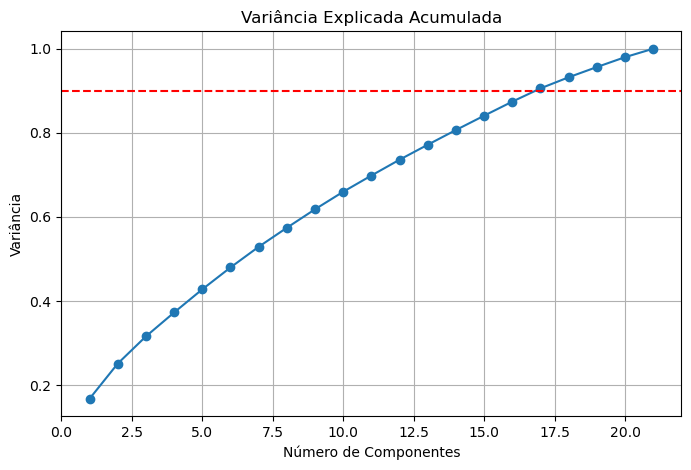

In [134]:
# Aplicando o PCA (usando os dados padronizados x_train_scaled que fizemos antes)

pca = PCA().fit(x_train_scaled)

# Cálculo da variância explicada acumulada
variancia_acumulada = np.cumsum(pca.explained_variance_ratio_)

# Verificando quantos componentes explicam 90% da variância
n_components = np.argmax(variancia_acumulada >= 0.90) + 1
print(f"Com {n_components} componentes conseguimos explicar 90% da variância dos dados.")

# Gráfico da Variância Explicada Acumulada
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(variancia_acumulada) + 1), variancia_acumulada, marker='o')
plt.axhline(y=0.90, color='r', linestyle='--')
plt.title('Variância Explicada Acumulada')
plt.xlabel('Número de Componentes')
plt.ylabel('Variância')
plt.grid()
plt.show()



In [135]:
# Criando o PCA com o número de componentes que explicam 90% da variância
pca_final = PCA(n_components=n_components)

# Aplicando o PCA nos dados de treino e teste
x_train_pca = pca_final.fit_transform(x_train_scaled)
x_test_pca = pca_final.transform(x_test_scaled)

print(f"Forma dos dados de treino após PCA: {x_train_pca.shape}")
print(f"Forma dos dados de teste após PCA: {x_test_pca.shape}")

Forma dos dados de treino após PCA: (176968, 17)
Forma dos dados de teste após PCA: (75844, 17)


*Desse modo reduzimos a dimensionalidade do dataset e eliminamos a multicolinearidade vista na matriz de correlação acima*

**Atenções a se ter na criação de modelos**
- O falso negativo na classificação de diabetes pode ter um risco imenso na vida de um paciente, desse modo, é pior darmos um resultado falso negativo que um falso positivo, portanto a otimização do modelo buscará a Recall (sensibilidade);
- A classe 0 em diabetes (pacientes sem diabetes) apresenta muito mais registros que a classe 1, desse modo precisamos usar técnicas como o PCA para filtrar ruídos, fazer uma boa divisão de teste e treino, além de usar métricas apropriadas;
- Além disso, importante que fique claro o modelo de diagnóstico que a IA está rodando, tendo em vista que o profissional da saúde pode precisar entender como está ocorrendo este diagnóstico e quais fatores estão influenciando nisso, até para atuar em prevenção com outros pacientes.

## Criando Classificador Linear com Perceptron

In [158]:
# usaremos dados sem estar transformados pelo PCA para treinar um modelo de Perceptron (x_train e x_test) e avaliar seu desempenho.

# Criando e treinando o modelo de Perceptron
perceptron = Perceptron(random_state=33)
perceptron.fit(x_train, y_train)

# Predições e avaliação sem pca
y_pred = perceptron.predict(x_test)

# Exibindo as métricas de avaliação
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}") #Acurácia é a proporção de previsões corretas (tanto verdadeiros positivos quanto verdadeiros negativos) em relação ao total de casos avaliados.
print(f"Precision: {precision_score(y_test, y_pred):.4f}") #Precisão é a proporção de verdadeiros positivos em relação ao total de casos que o modelo previu como positivos (verdadeiros positivos + falsos positivos).
print(f"Recall: {recall_score(y_test, y_pred):.4f}") #Recall é a proporção de verdadeiros positivos em relação ao total de casos que são realmente positivos (verdadeiros positivos + falsos negativos).
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}") #F1-Score é a média harmônica entre precisão e recall, fornecendo uma única métrica que equilibra ambos os aspectos. É especialmente útil quando há um desequilíbrio entre as classes, pois penaliza tanto falsos positivos quanto falsos negativos.

Accuracy: 0.8168
Precision: 0.3966
Recall: 0.3166
F1-Score: 0.3521


In [159]:
# usaremos dados transformados pelo PCA para treinar um modelo de Perceptron (x_train_pca e x_test_pca) e avaliar seu desempenho.

# Criando e treinando o modelo de Perceptron
perceptron2 = Perceptron(random_state=33)
perceptron2.fit(x_train_pca, y_train)

# Predições e avaliação
y_pred2 = perceptron2.predict(x_test_pca)

# Exibindo as métricas de avaliação
print(f"Accuracy: {accuracy_score(y_test, y_pred2):.4f}") #Acurácia é a proporção de previsões corretas (tanto verdadeiros positivos quanto verdadeiros negativos) em relação ao total de casos avaliados.
print(f"Precision: {precision_score(y_test, y_pred2):.4f}") #Precisão é a proporção de verdadeiros positivos em relação ao total de casos que o modelo previu como positivos (verdadeiros positivos + falsos positivos).
print(f"Recall: {recall_score(y_test, y_pred2):.4f}") #Recall é a proporção de verdadeiros positivos em relação ao total de casos que são realmente positivos (verdadeiros positivos + falsos negativos).
print(f"F1-Score: {f1_score(y_test, y_pred2):.4f}") #F1-Score é a média harmônica entre precisão e recall, fornecendo uma única métrica que equilibra ambos os aspectos. É especialmente útil quando há um desequilíbrio entre as classes, pois penaliza tanto falsos positivos quanto falsos negativos.

Accuracy: 0.7645
Precision: 0.3102
Recall: 0.4066
F1-Score: 0.3519


In [160]:
# Código para extrair os parâmetros
print("Coeficientes (Pesos):", perceptron.coef_)
print("Bias (Intercepto):", perceptron.intercept_)


pesos = pd.Series(perceptron.coef_[0], index=x_train.columns)
print(pesos.sort_values(ascending=False))

Coeficientes (Pesos): [[ 292.  267.  380.    7.  -21.   76.  158.   -1.    9.  -13. -258.   22.
     7.  184.   21.   24.   56.  101.   66.  -11.  -19.]]
Bias (Intercepto): [-2658.]
CholCheck               380.0
HighBP                  292.0
HighChol                267.0
GenHlth                 184.0
HeartDiseaseorAttack    158.0
Sex                     101.0
Stroke                   76.0
Age                      66.0
DiffWalk                 56.0
PhysHlth                 24.0
AnyHealthcare            22.0
MentHlth                 21.0
Fruits                    9.0
NoDocbcCost               7.0
BMI                       7.0
PhysActivity             -1.0
Education               -11.0
Veggies                 -13.0
Income                  -19.0
Smoker                  -21.0
HvyAlcoholConsump      -258.0
dtype: float64


As Bias deslocam o hiperplano da origem, ajudando a definir o limiar da decisão;
Os coeficiente (coef) indicam a importância e a direção de cada feature (quanto maior o coeficiente, maior a chance de correlação com diabete)
<br>
<br>
As colunas mais determinantes (com maior coeficiente) doram CholCheck, HighBP, HighChol e HeartDiseaseorAttack, deixando com menos importância fatores fundamentais como idade por exemplo, isso demonstra que não houve um bom aproveitamento das colunas, se fosse comparar os pesos usados pelo perceptron e o que um profissional da saúde usaria. Isso se reflete nos baixos índices usados.




O modelo de perceptron que usou como base o PCA tem um desempenho inferior ao modelo que usou os dados originais, apesar de uma melhor recall. <br>
Isso pode ocorrer porque o PCA, ao reduzir a dimensionalidade, pode ter perdido informações importantes para a classificação, <br>
especialmente se as componentes principais não capturaram bem a variância relevante para a variável alvo. <br>
Além disso, o modelo de perceptron é linear e pode não ser capaz de capturar relações complexas entre as features, o que pode ser exacerbado <br>
pela redução de dimensionalidade do PCA.

Podemos verificar que o perceptron não apresentou um bom funcionamento para a análise dos dados:
- A acurácia está "alta", mas se chutassemos tudo como sem diabete, teriamos um acerto maior (aproximadamente 84%) e sem custo nenhum;
- A precisão de 31% mostra que esse sistema geraria um alto número de falsos positivos (69% aproximadamente), o que aumentaria muito o custo de atenção a cada paciente sem necessidade (exames, consultas);
- O recall com cerca de 41% mostra que teríamos um alto número de falsos negativos, o que para o nosso caso de saúde é péssimo, tendo em vista que não iríamos ter um olhar mais cuidadoso com 59% dos pacientes com pré-diabete/diabete, podendo levar a casos de amputações e até óbitos;
- O F1-score de 35% mostra que o modelo perceptron não atingiu um bom equilíbrio entre as métricas e mostrando sua ineficiência

Desse modo, vemos as limitações do modelo perceptron para a análise do nosso dataset, mostrando que ocorreu um underfitting da análise e provavelmente sofreu desbalanceamento de alguma classe. Além disso, vemos que mesmo com o PCA e redução de multicolinearidade, um classificador linear só consegue separar dados em um hiperplano rígido, o que não é o caso do nosso dataset, onde a diabete teminfluências diversas, resultando em interações complexas e não-lineares entre as variáveis. <br>
Assim, vamos seguir evoluindo o sistema para modelos mais complexos em busca de melhores resultados, usando os resultados obtidos como "régua" a ser ultrapassada.

## Criando modelo de Árvore de Decisão

In [137]:
# Testar pipeline para ver diferentes profundidades da árvore e comparar os resultados

pipe = Pipeline([
    ('arvore2', DecisionTreeClassifier(random_state=33, class_weight='balanced'))
])

parametros = {
    'arvore2__max_depth': [3, 5, 7, 10, 15],
    'arvore2__min_samples_split': [2, 5, 10, 20, 50]
}

# Usar recall como base pq queremos minimizar os falsos negativos (pessoas com diabetes que o modelo não identificou) e class_weight='balanced' para lidar com o desequilíbrio da classe alvo.
grid = GridSearchCV(pipe, parametros, cv=5, scoring='recall', n_jobs=1) #n_jobs = 1 para evitar problemas de paralelismo em notebooks

# Treinando o GridSearchCV
grid.fit(x_train_scaled, y_train)

# Exibindo os melhores parâmetros e o melhor score
print(f"Melhores Parâmetros: {grid.best_params_}")
print(f"Melhor Recall: {grid.best_score_:.4f}")

Melhores Parâmetros: {'arvore2__max_depth': 3, 'arvore2__min_samples_split': 2}
Melhor Recall: 0.8241


In [138]:
# Avaliando o melhor modelo final
best_model = grid.best_estimator_ #Vai pegar o modelo treinado com os melhores parâmetros encontrados no GridSearchCV
y_pred_final = best_model.predict(x_test_scaled)

print("Relatório do Melhor Modelo de Árvore:")
print(classification_report(y_test, y_pred_final))

Relatório do Melhor Modelo de Árvore:
              precision    recall  f1-score   support

         0.0       0.95      0.59      0.73     63916
         1.0       0.28      0.82      0.41     11928

    accuracy                           0.63     75844
   macro avg       0.61      0.71      0.57     75844
weighted avg       0.84      0.63      0.68     75844



Podemos realizar uma comparação entre o modelo de árvore de decisão (de profundidade 3 e mínimo de 2 amostras necessárias para dividir um nó da árvore) que tivemos os melhores resultados e o perceptron:
- Acurácia: Apesar de uma aparente queda da acurácia (76% para 63%), o modelo do perceptron "chutava" a classe mais frequente, enquanto a árvore de decisão devido ao class_weight erra mais visando encontrar os pacientes com diabete;
- Precisão: Uma leve queda de 31% para 28%, foi o custo buscando obter um melhor recall, que é o parametro que estabelecemos como de maior importância;
- Recall: Saiu de 40,6% para 82%, ou seja, em cada 10 pacientes diabéticos/pre-diabéticos, somente 2 não são identificados.
- F1-Score: Um aumento de 36% para 41%, indicando que a melhora do recall (mesmo as custas da dimunição da precisão) foram de fato eficiente, mostrando que a árvore de decisões foi um modelo melhor que o perceptron. Cabe lembrar que a busca pelo melhor recall vai contribuir para uma perca no F1-score.


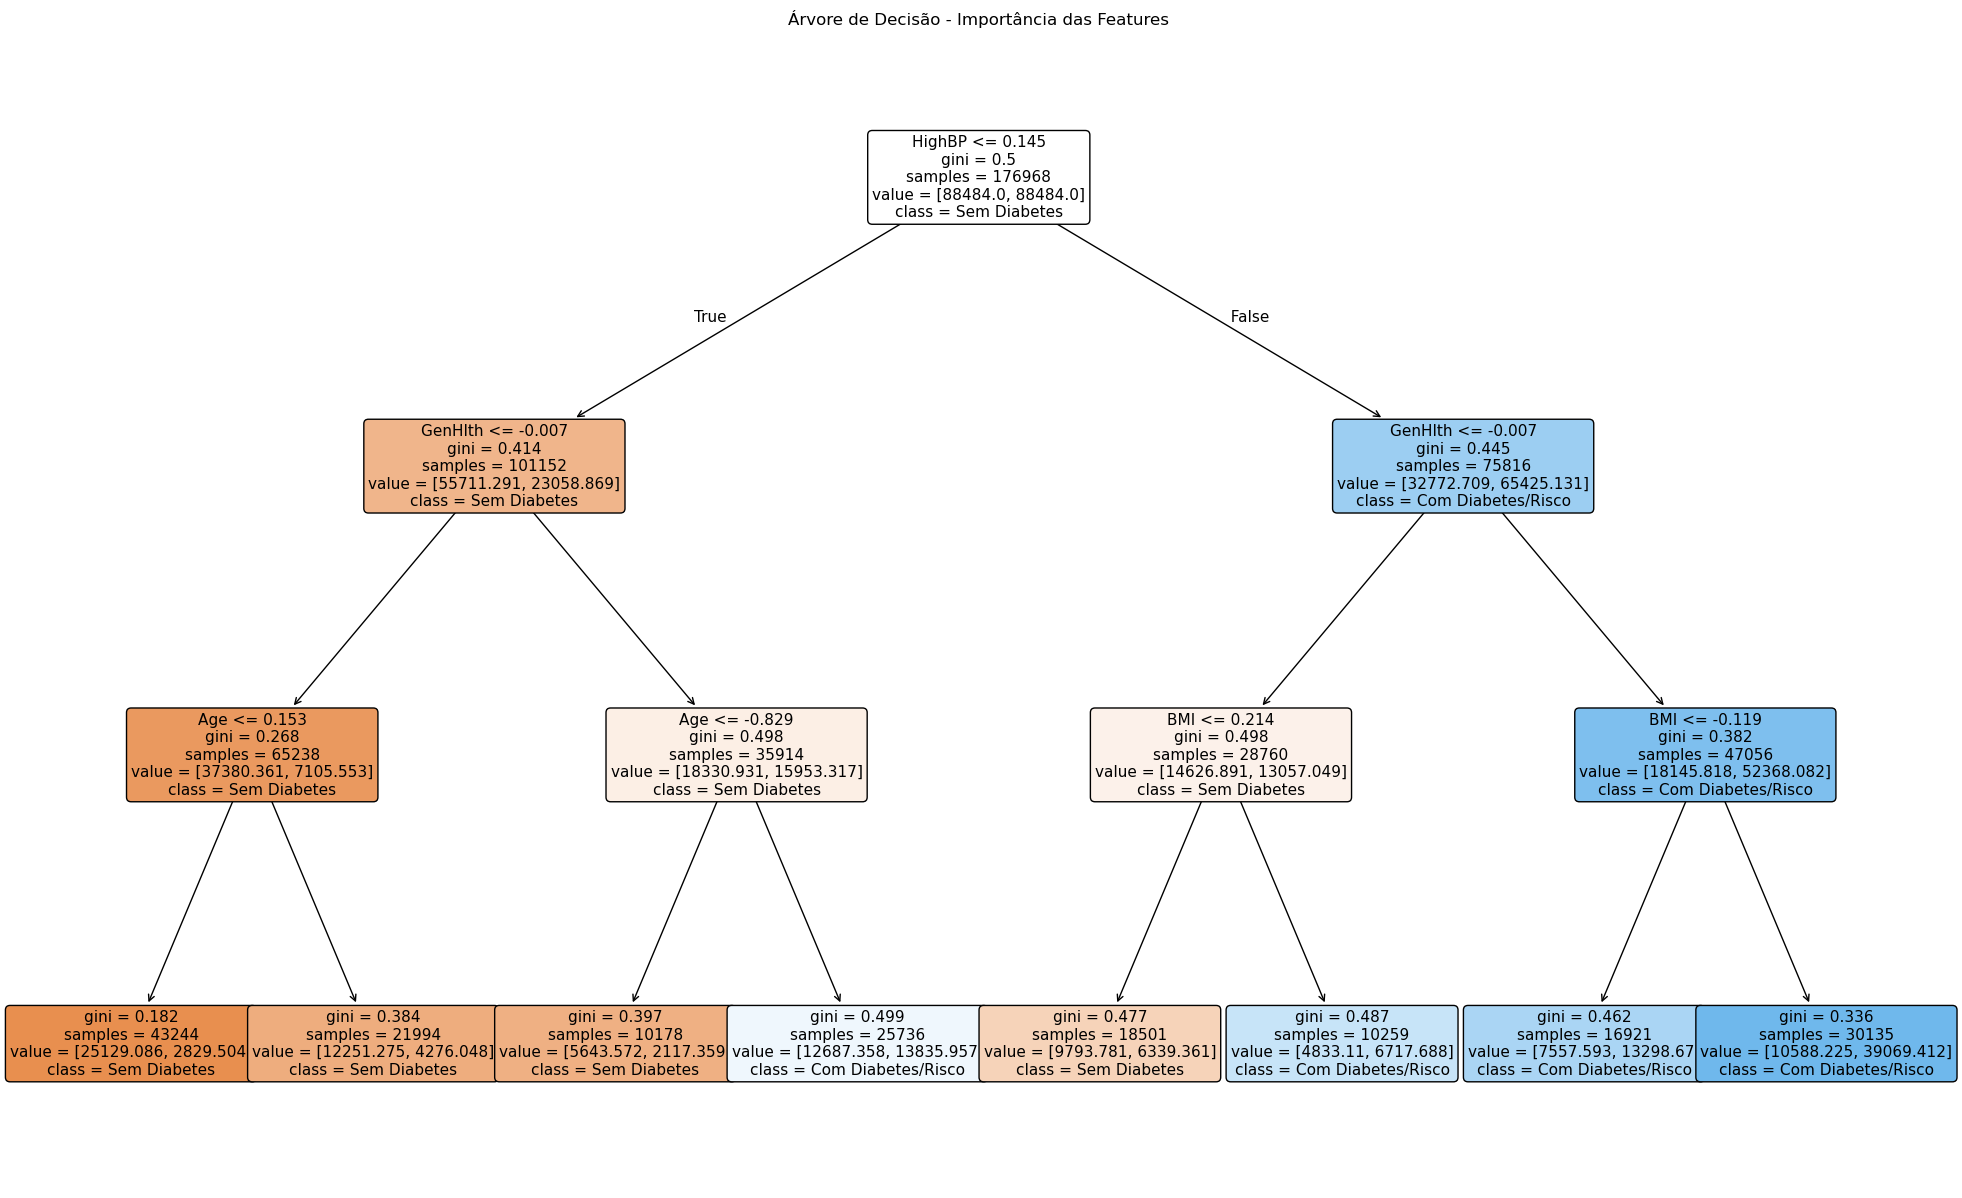

In [139]:
# Criando gráfico para ver a importância das features no modelo de árvore de decisão
best_model_arvore = best_model.named_steps['arvore2'] #Acessando o modelo de árvore dentro do pipeline

# criando um DataFrame para visualizar a importância das features
plt.figure(figsize=(25, 15))
plot_tree(best_model_arvore, 
          feature_names=x_test.columns,
           class_names=['Sem Diabetes', 'Com Diabetes/Risco'],
           filled=True,
           rounded=True,
           fontsize=11)
plt.title('Árvore de Decisão - Importância das Features')
plt.show()

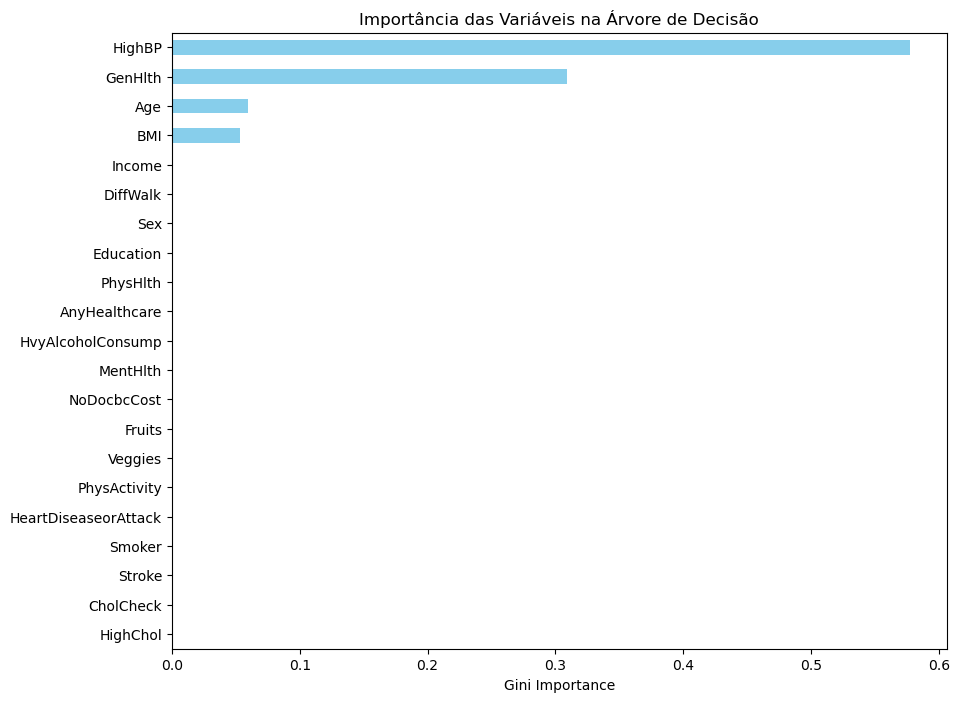

In [140]:
importances = pd.Series(best_model_arvore.feature_importances_, index=x_test.columns)
importances.sort_values().plot(kind='barh', figsize=(10, 8), color='skyblue')
plt.title("Importância das Variáveis na Árvore de Decisão")
plt.xlabel("Gini Importance")
plt.show()

Observar que utilizei a árvore de decisões no dataframe sem PCA para poder facilitar avaliar quais as colunas mais importantes na árvore de decisão e correlacionar com o conhecimento sobre a área de saúde.
- O fator mais importante foi a Alta pressão arterial: Um marcador importante para a Síndrome Plurimetabólica, normalmente associada a diabetes;
- Em seguida temos a Saúde Geral, que é a autoavaliação do paciente sobre sua saúde, considerando que um corpo com resistência à insulina vai apresentar sinais e sintomas no organismo, natural que o paciente perceba alteração na sua saúde;
- Idade avançada é extremamente associada a diabete tipo 2, principalmente por ser um "acumulado" de maus hábitos alimentares e físicos;
- Fechando temos o IMC, que é de conhecimento geral que excesso de tecido adiposo aumenta inflamação corporal e resistência à insulina, fortemente correlacionado à diabete tipo 2.

Importante observar que a flexibilidade da árvore de decisões permitiu criar interações entre variáveis como Age (Idade) e BMI (IMC), coisa que o perceptron não conseguiu. Entretanto, corre o risco de causar regras muito rígidas (como BMI > 28,5 ser definitivo para diabete), causando um overfitting, ressaltando a importância de limitarmos a profundidade da nossa árvore, além de conferirmos se as variáveis escolhidas condizem com a realidaed médica. <br>
<br>A recall em torno de 80% é um bom sinalizador de aprendizado do modelo

## Validação Cruzada e Busca de Hiperparâmetros

In [141]:
# Agora vamos testar o modelo de árvore de decisão usando os dados transformados pelo PCA para ver se conseguimos melhorar o desempenho,
# especialmente em termos de recall.
pipe_cv = Pipeline([
    ('scaler', StandardScaler()),
    #('pca', PCA(n_components=n_components)),
    ('dt', DecisionTreeClassifier(class_weight='balanced', random_state=33))
])

# Espaço de busca focado em Regularização (evitar overfitting)
param_grid = {
    'dt__max_depth': [3, 5, 7, 10, 15],
    'dt__min_samples_split': [10, 20, 30, 50],
    'dt__criterion': ['gini', 'entropy'] #Adicionando o critério de divisão para ver se isso ajuda a melhorar o recall
}

# Validação Cruzada (5-fold) 
# Usamos StratifiedKFold implicitamente pelo GridSearchCV para manter proporção de diabéticos
grid_search = GridSearchCV(pipe_cv, param_grid, cv=5, scoring='recall', n_jobs=-1, return_train_score=True) #n_jobs=-1 para usar todos os processadores disponíveis e acelerar o processo de busca
grid_search.fit(x_train, y_train)

# Melhor modelo
best_model_arvore2 = grid_search.best_estimator_

In [142]:
# Analisando a variação dos resultados
resultados = grid_search.cv_results_
mean_recall = resultados['mean_test_score'][grid_search.best_index_]
std_recall = resultados['std_test_score'][grid_search.best_index_]

print(f"Recall Médio (CV): {mean_recall:.4f}")
print(f"Desvio Padrão do Recall: {std_recall:.4f}")
print(f"Melhores Parâmetros: {grid_search.best_params_}")
print(f"Melhor Recall: {grid_search.best_score_:.4f}")

Recall Médio (CV): 0.8278
Desvio Padrão do Recall: 0.0099
Melhores Parâmetros: {'dt__criterion': 'entropy', 'dt__max_depth': 3, 'dt__min_samples_split': 10}
Melhor Recall: 0.8278


In [143]:
best_model_arvore2 = grid_search.best_estimator_ #Vai pegar o modelo treinado com os melhores parâmetros encontrados no GridSearchCV
y_pred_final2 = best_model_arvore2.predict(x_test)

print("Relatório do Melhor Modelo de Árvore:")
print(classification_report(y_test, y_pred_final2))

Relatório do Melhor Modelo de Árvore:
              precision    recall  f1-score   support

         0.0       0.95      0.59      0.73     63916
         1.0       0.28      0.82      0.41     11928

    accuracy                           0.63     75844
   macro avg       0.61      0.71      0.57     75844
weighted avg       0.84      0.63      0.68     75844



In [144]:
# Agora otimizando pelo F1-Score para equilibrar Precisão e Recall
grid_search2 = GridSearchCV(
    pipe_cv, 
    param_grid, 
    cv=5, 
    scoring='f1', # mudamos para F1-Score para tentar equilibrar precisão e recall, já que o recall sozinho pode levar a muitos falsos positivos
    n_jobs=-1, 
    return_train_score=True
)

grid_search2.fit(x_train, y_train)

# Verifique os novos "Melhores Parâmetros"
print(f"Melhores Parâmetros (F1): {grid_search2.best_params_}")
print(f"Melhor F1-Score: {grid_search2.best_score_:.4f}")

Melhores Parâmetros (F1): {'dt__criterion': 'entropy', 'dt__max_depth': 10, 'dt__min_samples_split': 50}
Melhor F1-Score: 0.4542


In [145]:
# Avaliando o melhor modelo final com métrica F1
best_model_arvore3 = grid_search2.best_estimator_
best_model_arvore3 = grid_search2.best_estimator_ #Vai pegar o modelo treinado com os melhores parâmetros encontrados no GridSearchCV
y_pred_final3 = best_model_arvore3.predict(x_test)

print("Relatório do Melhor Modelo de Árvore:")
print(classification_report(y_test, y_pred_final3))

Relatório do Melhor Modelo de Árvore:
              precision    recall  f1-score   support

         0.0       0.94      0.68      0.79     63916
         1.0       0.31      0.79      0.45     11928

    accuracy                           0.70     75844
   macro avg       0.63      0.73      0.62     75844
weighted avg       0.85      0.70      0.74     75844



In [163]:
scores = cross_val_score(best_model_arvore3, x_test_scaled, y_test, cv=5, scoring='f1')

print(f"F1-Score por fold: {scores}")

print(f"Média: {scores.mean():.4f}")

print(f"Desvio Padrão: {scores.std():.4f}")

F1-Score por fold: [0.45100294 0.44516451 0.45186492 0.45436459 0.45302056]
Média: 0.4511
Desvio Padrão: 0.0032


O modelo apresentou um desvio padrão baixo (0,0032), indicando uma robustez do sistema, que o desempenho não dependeu de um corte especifico dos dadoss

Com o baixo desvio padrão do recall e a recall média tendo o mesmo valor da melhore recall, vemos que o modelo ficou bem estável entre os 5 folds da validação cruzada. Desse modo, vemos que as regras aprendidas não dependem de uma participação específica de dados dos pacientes

A busca por hiperparâmetros (como max_depth e min_samples_split) é uma busca por regularização <br>
- Ao limitarmos a profundidade por exemplo, evitamos ter folhas com um único paciente por exemplo, simplificando a estrutura;
- Interpretabilidade é, normalmente, maior em um modelo otimizado. Uma árvore muito profunda para se ler e interpretar fica difícil
- No modelo com recall, entendi que ele estava buscando os valores provavelmente de forma muito determinista, explicado o porque de usar somente menor profundidade (talvez ocorrendo um underfitting), atribuindo a busca pelo f1-score, mantivemos o recall e a precisão similares, entretanto, garantimos uma melhor generalização (evidenciado até pelo min_samples_split no valor de 50), ou seja, que o modelo deve funcionar bem com novos pacientes

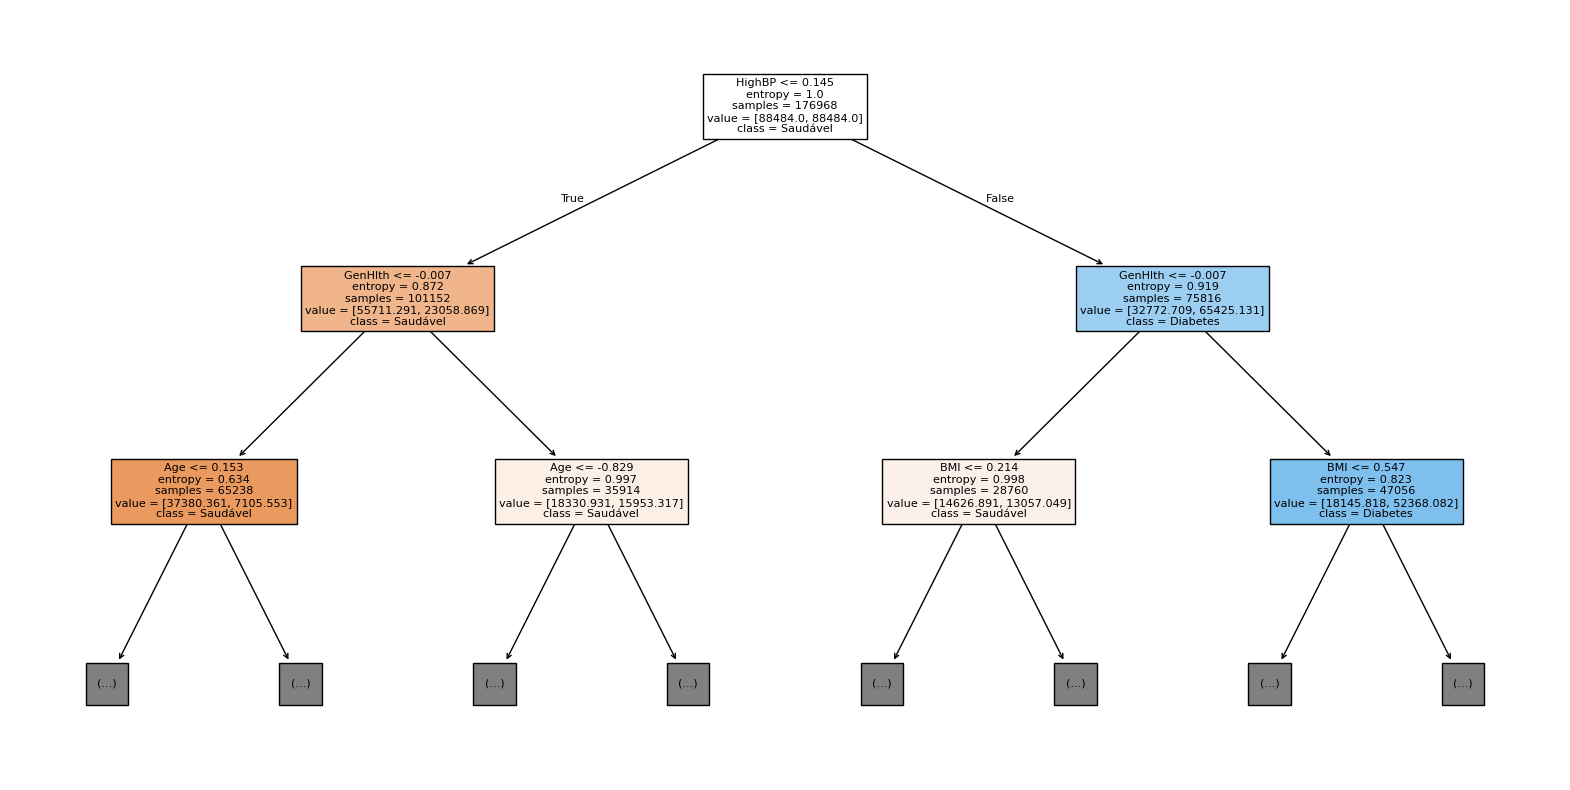

In [167]:
plt.figure(figsize=(20,10))
tree_model = best_model_arvore3.named_steps['dt']  # ← Extrai só a árvore
plot_tree(tree_model, feature_names=x_train.columns, class_names=['Saudável', 'Diabetes'], max_depth=2, filled=True)
plt.show()

Analisando os caminhos da árvore (melhor modelo), vemos que:
- A regra principal foi o HighBP, onde <= 0,145 (ponto onde a impureza é mais reduzida para separar os grupos) ele considerou como saudável;
- Em seguida ele avaliou o GenHlth <= 0,007 para continuar a separação

In [146]:
# Modelo 1: Árvore Simples (Baseline)
p1 = precision_score(y_test, y_pred_final, pos_label=1.0)
r1 = recall_score(y_test, y_pred_final, pos_label=1.0)

# Modelo 2: Otimizada Recall (aquela com depth 3)
p2 = precision_score(y_test, y_pred_final2, pos_label=1.0)
r2 = recall_score(y_test, y_pred_final2, pos_label=1.0)

# Modelo 3: Otimizada F1 (a melhor, com depth 10)
p3 = precision_score(y_test, y_pred_final3, pos_label=1.0)
r3 = recall_score(y_test, y_pred_final3, pos_label=1.0)

# Criando as listas automáticas para o gráfico
precisions = [p1, p2, p3]
recalls = [r1, r2, r3]

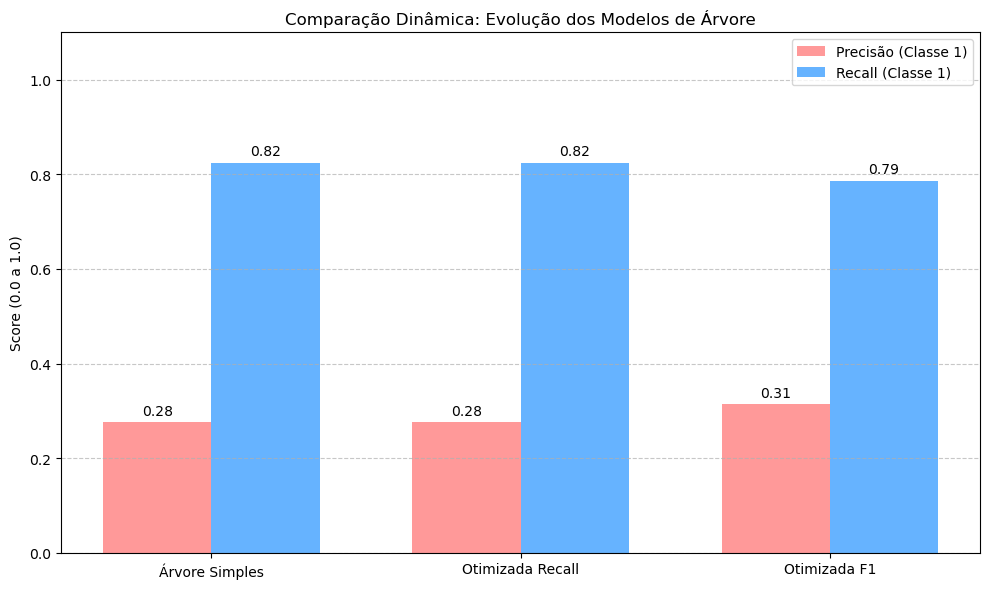

In [147]:
labels = ['Árvore Simples', 'Otimizada Recall', 'Otimizada F1']
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

# Usando as variáveis que extraímos acima
rects1 = ax.bar(x - width/2, precisions, width, label='Precisão (Classe 1)', color='#ff9999')
rects2 = ax.bar(x + width/2, recalls, width, label='Recall (Classe 1)', color='#66b3ff')

ax.set_ylabel('Score (0.0 a 1.0)')
ax.set_title('Comparação Dinâmica: Evolução dos Modelos de Árvore')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.1) # Garantindo espaço para as etiquetas em cima
ax.legend()

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.grid(axis='y', linestyle='--', alpha=0.7)
fig.tight_layout()
plt.show()

Apesar de a última versão ter um recall um pouco menor, ele conseguiu elevar a precisão e foi o mais generalista dos modelos criados até agora

## Modelos Avançados: SVM ou Ensembles

**Usaremos o RandomForest para essa etapa**

In [148]:
# Criação do Pipeline (Mantendo o Scaler para consistência com os modelos anteriores)
pipe_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(class_weight='balanced', random_state=33))
])

# Espaço de busca (Hiperparâmetros relevantes para Ensemble)
param_grid_rf = {
    'rf__n_estimators': [100, 150, 200], # Número de árvores na floresta
    'rf__max_depth': [5, 10, 15], # Profundidade para controlar overfitting
    'rf__max_features': ['sqrt', 'log2'], # Número de colunas sorteadas para cada árvore
    'rf__min_samples_leaf': [10, 20, 50] # Regularização via tamanho das folhas
}

# GridSearchCV (Otimizando pelo F1-Score para manter o equilíbrio)
grid_rf = GridSearchCV(pipe_rf, param_grid_rf, cv=5, scoring='f1', n_jobs=-1)
grid_rf.fit(x_train, y_train)

# Melhor modelo e predições
best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(x_test)

print(f"Melhores Parâmetros RF: {grid_rf.best_params_}")
print(classification_report(y_test, y_pred_rf))

Melhores Parâmetros RF: {'rf__max_depth': 15, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 10, 'rf__n_estimators': 150}
              precision    recall  f1-score   support

         0.0       0.94      0.75      0.83     63916
         1.0       0.35      0.74      0.48     11928

    accuracy                           0.75     75844
   macro avg       0.65      0.74      0.66     75844
weighted avg       0.85      0.75      0.78     75844



In [149]:
# Criação do Pipeline (Mantendo o Scaler para consistência com os modelos anteriores)
pipe_rf2 = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(class_weight='balanced', random_state=33))
])

# Espaço de busca (Hiperparâmetros relevantes para Ensemble)
param_grid_rf = {
    'rf__n_estimators': [100, 150, 200], # Número de árvores na floresta
    'rf__max_depth': [5, 10, 15], # Profundidade para controlar overfitting
    'rf__max_features': ['sqrt', 'log2'], # Número de colunas sorteadas para cada árvore
    'rf__min_samples_leaf': [10, 20, 50] # Regularização via tamanho das folhas
}

# GridSearchCV (Otimizando pelo F1-Score para manter o equilíbrio)
grid_rf = GridSearchCV(pipe_rf, param_grid_rf, cv=5, scoring='recall', n_jobs=-1)
grid_rf.fit(x_train, y_train)

# Melhor modelo e predições
best_rf2 = grid_rf.best_estimator_
y_pred_rf2 = best_rf2.predict(x_test)

print(f"Melhores Parâmetros RF: {grid_rf.best_params_}")
print(classification_report(y_test, y_pred_rf2))

Melhores Parâmetros RF: {'rf__max_depth': 10, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 50, 'rf__n_estimators': 150}
              precision    recall  f1-score   support

         0.0       0.94      0.71      0.81     63916
         1.0       0.33      0.78      0.47     11928

    accuracy                           0.72     75844
   macro avg       0.64      0.74      0.64     75844
weighted avg       0.85      0.72      0.76     75844



Fiz uma tentativa de mudança aqui no random forest para focar em recall ao invés de F1-score, entretanto, os valores se mantiveram praticamente os mesmos, uma pequena perda de f1-score, mas uma melhora de recall (saindo de 74% para 78%). Como nosso foco é evitar falsos negativos, creio ser o melhor modelo a utilizarmos

In [150]:
# Inserido os f1-scores
f1 = f1_score(y_test, y_pred_final)
f2 = f1_score(y_test, y_pred_final2)
f3 = f1_score(y_test, y_pred_final3)

# Modelo 4: Random Forest Otimizada
p4 = precision_score(y_test, y_pred_rf, pos_label=1.0)
r4 = recall_score(y_test, y_pred_rf, pos_label=1.0)
f4 = f1_score(y_test, y_pred_rf)

# Modelo 5: Random Forest Otimizada para Recall
p5 = precision_score(y_test, y_pred_rf2, pos_label=1.0)
r5 = recall_score(y_test, y_pred_rf2, pos_label=1.0)
f5 = f1_score(y_test, y_pred_rf2)


# Criando as listas automáticas para o gráfico
precisions2 = [p1, p2, p3, p4, p5]
recalls2 = [r1, r2, r3, r4, r5]
f1score = [f1, f2, f3, f4, f5]

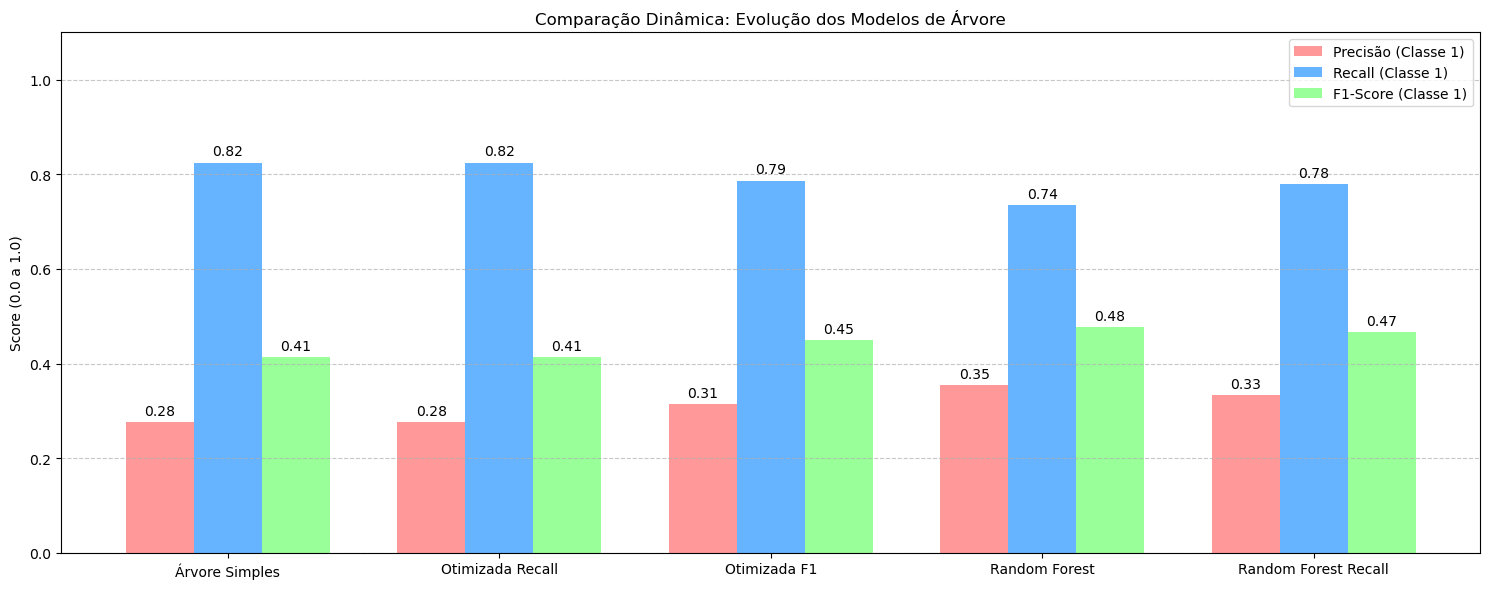

In [151]:
labels2 = ['Árvore Simples', 'Otimizada Recall', 'Otimizada F1', 'Random Forest', 'Random Forest Recall']
x = np.arange(len(labels2))
width = 0.25

fig, ax = plt.subplots(figsize=(15, 6))

# Usando as variáveis que extraímos acima
rects3 = ax.bar(x - width, precisions2, width, label='Precisão (Classe 1)', color='#ff9999')
rects4 = ax.bar(x, recalls2, width, label='Recall (Classe 1)', color='#66b3ff')
rects5 = ax.bar(x + width, f1score, width, label='F1-Score (Classe 1)', color='#99ff99')

ax.set_ylabel('Score (0.0 a 1.0)')
ax.set_title('Comparação Dinâmica: Evolução dos Modelos de Árvore')
ax.set_xticks(x)
ax.set_xticklabels(labels2)
ax.set_ylim(0, 1.1) # Garantindo espaço para as etiquetas em cima
ax.legend()

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects3)
autolabel(rects4)
autolabel(rects5)

plt.grid(axis='y', linestyle='--', alpha=0.7)
fig.tight_layout()
plt.show()

Apesar de não ter tanta variação e aparentar ser meio contra intuitivo, o modelo do Random Forest teve o melhor F1- score entre os modelos, atingindo 0.48, além de um aumento na precisão, o que significa que reduzimos os falsos positivos, porém mantivemos um valor alto de Recall

In [152]:
# Extraindo a importância das colunas do melhor Random Forest
importancias = best_rf2.named_steps['rf'].feature_importances_
features = x_train.columns

# Criando um DataFrame para facilitar a visualização
df_importancia = pd.DataFrame({'Feature': features, 'Importância': importancias})
df_importancia = df_importancia.sort_values(by='Importância', ascending=False)

print("Ordem de Importância das Variáveis no Random Forest:")
print(df_importancia)

Ordem de Importância das Variáveis no Random Forest:
                 Feature  Importância
13               GenHlth     0.239907
0                 HighBP     0.224458
3                    BMI     0.133443
18                   Age     0.105796
1               HighChol     0.100943
16              DiffWalk     0.053349
15              PhysHlth     0.029246
6   HeartDiseaseorAttack     0.028860
20                Income     0.028627
19             Education     0.011606
7           PhysActivity     0.007742
2              CholCheck     0.007119
10     HvyAlcoholConsump     0.006144
17                   Sex     0.005914
14              MentHlth     0.005748
5                 Stroke     0.003204
4                 Smoker     0.002822
8                 Fruits     0.001945
9                Veggies     0.001815
12           NoDocbcCost     0.000786
11         AnyHealthcare     0.000526


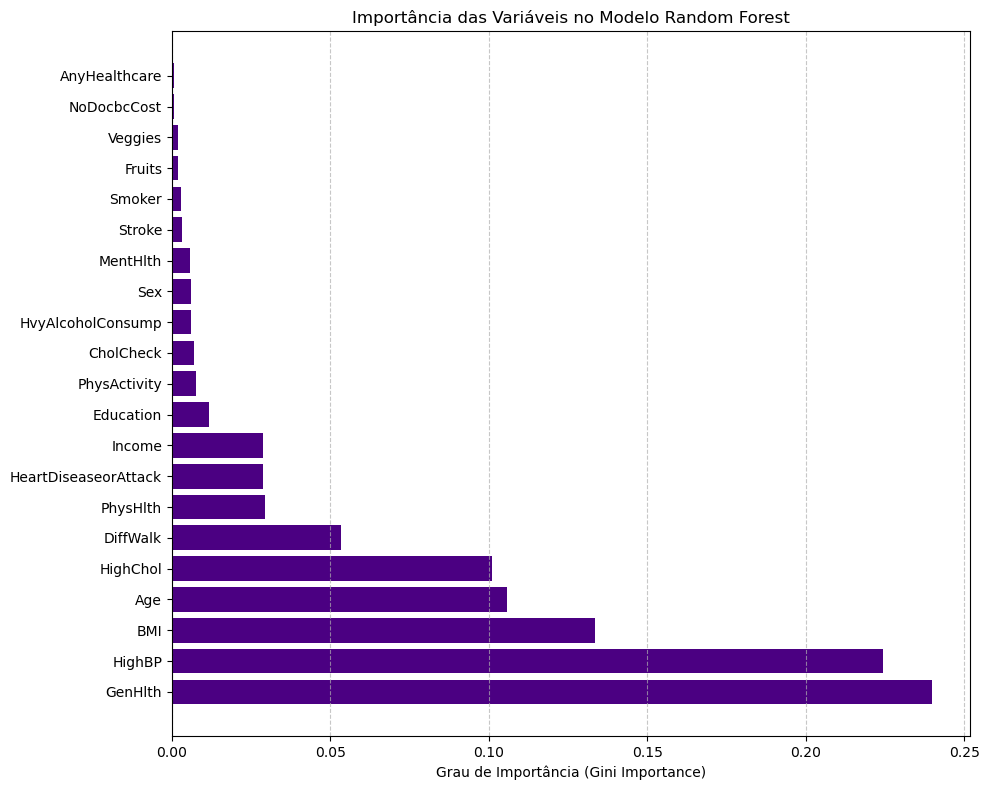

In [153]:
# Plotando a Importância das Variáveis
plt.figure(figsize=(10, 8))
plt.barh(df_importancia['Feature'], df_importancia['Importância'], color='#4b0082')
plt.xlabel('Grau de Importância (Gini Importance)')
plt.title('Importância das Variáveis no Modelo Random Forest')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


A lógica empregada pelo Random forest confirma a importância das variáveis GenHlth, HighBP, BMI e Age, o que bate com o consenso da área de saúde, conforme tinhamos citado anteriormente.  


O Random Forest é um modelo mais complexo, tenho um custo computacional mais cara que o perceptron, entretanto, é um sistema menos propenso a erro de classificação por ruído, sendo assim um classificador mais seguro para novos pacientes que sejam avaliados por este modelo, como podemos perceber por um melhor f1-score.

Como resumo dos passos percorridos, temos:
- Perceptron: Underfitting (Recall baixo);
- Árvore Simples: Boa ideia, mas instável;
- Árvore Otimizada: Melhorou o Recall, mas com Underfitting (depth 3) ou Precision baixa;
- Random Forest: O melhor equilíbrio. Robusto, preciso e seguro.